In [1]:
import os
import glob
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error
import celer
VALID_STATES = set(['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY'])

unknown delay: exponential weights in xueda’s paper might not be generalizable when the delay’s unknown and change across time -> group lasso

In [2]:
target_files = ['./target/covidcast-dsew-cpr-confirmed_admissions_covid_1d_7dav-2020-12-16-to-2023-02-21.csv',
 './target/covidcast-hhs-confirmed_admissions_covid_1d-2019-12-31-to-2024-04-26.csv',
 './target/covidcast-jhu-csse-confirmed_incidence_num-2020-01-22-to-2023-03-09.csv',
 './target/covidcast-jhu-csse-deaths_incidence_num-2020-01-22-to-2023-03-09.csv',
 './target/covidcast-usa-facts-confirmed_incidence_num-2020-01-25-to-2023-01-02.csv',
 './target/covidcast-usa-facts-deaths_incidence_num-2020-01-25-to-2023-01-02.csv']
aux_files = [
#  './auxiliary/covidcast-chng-smoothed_outpatient_cli-2020-02-01-to-2024-02-14.csv',
#  './auxiliary/covidcast-chng-smoothed_outpatient_covid-2020-02-01-to-2024-02-14.csv',
#  './auxiliary/covidcast-doctor-visits-smoothed_cli-2020-02-01-to-2024-04-26.csv',
 './auxiliary/covidcast-fb-survey-raw_wcli-2020-04-06-to-2022-06-25.csv',
 './auxiliary/covidcast-fb-survey-raw_whh_cmnty_cli-2020-04-06-to-2022-06-25.csv',
 './auxiliary/covidcast-fb-survey-smoothed_wtested_14d-2020-04-06-to-2022-06-25.csv',
 './auxiliary/covidcast-fb-survey-smoothed_wtested_positive_14d-2020-04-06-to-2022-06-25.csv',
 './auxiliary/covidcast-google-symptoms-s01_raw_search-2019-12-31-to-2024-04-26.csv',
 './auxiliary/covidcast-google-symptoms-s02_raw_search-2019-12-31-to-2024-04-26.csv',
 './auxiliary/covidcast-google-symptoms-s03_raw_search-2019-12-31-to-2024-04-26.csv',
 './auxiliary/covidcast-google-symptoms-s04_raw_search-2019-12-31-to-2024-04-26.csv',
 './auxiliary/covidcast-google-symptoms-s05_raw_search-2019-12-31-to-2024-04-26.csv',
 './auxiliary/covidcast-google-symptoms-s06_raw_search-2019-12-31-to-2024-04-26.csv',
 './auxiliary/covidcast-google-symptoms-s07_raw_search-2019-12-31-to-2024-04-26.csv',
 './auxiliary/covidcast-quidel-covid_ag_raw_pct_positive-2020-05-26-to-2024-04-26.csv']

In [3]:
# =========================
# IO: read signal csv -> wide df (index=time_value, columns=geo_value)
# =========================
def read_signal_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "time_value" not in df.columns or "geo_value" not in df.columns or "value" not in df.columns:
        raise ValueError(f"{path} must contain columns time_value, geo_value, value")

    df["time_value"] = pd.to_datetime(df["time_value"])
    df["geo_value"] = df["geo_value"].astype(str).str.upper()

    # If issue_date exists, keep latest issue_date for each (geo, time) but do NOT use versioning
    if "issue_date" in df.columns:
        df["issue_date"] = pd.to_datetime(df["issue_date"])
        df = df.sort_values(["geo_value", "time_value", "issue_date"])
        df = df.groupby(["geo_value", "time_value"], as_index=False).tail(1)

    wide = df.pivot(index="time_value", columns="geo_value", values="value").sort_index()
    wide = wide.fillna(0.0)
    # # optional light imputation for tiny gaps + fill remaining with 0 (to keep samples)
    # if FILL_MISSING_WITH_ZERO:
    #     wide = wide.interpolate(method="time", limit=LIMIT_INTERP_DAYS, limit_area="inside")
    #     wide = wide.ffill(limit=LIMIT_INTERP_DAYS).bfill(limit=LIMIT_INTERP_DAYS)
    #     wide = wide.fillna(0.0)
    return wide

In [4]:
# Load all signals
signal_wides = {}

# targets
for fp in target_files:
    name = os.path.splitext(os.path.basename(fp))[0]
    print("Loading target:", name)
    signal_wides[name] = read_signal_csv(fp)
    print(sorted(set(signal_wides[name].columns)))

# auxiliary
for fp in aux_files:
    name = os.path.splitext(os.path.basename(fp))[0]
    if name == "fetch":
        continue
    print("Loading auxiliary:", name)
    signal_wides[name] = read_signal_csv(fp)
    print(sorted(set(signal_wides[name].columns)))

VALID_STATES = set.intersection(
    *(set(df.columns) for df in signal_wides.values())
)

Loading target: covidcast-dsew-cpr-confirmed_admissions_covid_1d_7dav-2020-12-16-to-2023-02-21
['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'GU', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MP', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VI', 'VT', 'WA', 'WI', 'WV', 'WY']
Loading target: covidcast-hhs-confirmed_admissions_covid_1d-2019-12-31-to-2024-04-26
['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VI', 'VT', 'WA', 'WI', 'WV', 'WY']
Loading target: covidcast-jhu-csse-confirmed_incidence_num-2020-01-22-to-2023-03-09
['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', '

In [5]:
target_names = [os.path.splitext(os.path.basename(fp))[0] for fp in target_files]
target_names

['covidcast-dsew-cpr-confirmed_admissions_covid_1d_7dav-2020-12-16-to-2023-02-21',
 'covidcast-hhs-confirmed_admissions_covid_1d-2019-12-31-to-2024-04-26',
 'covidcast-jhu-csse-confirmed_incidence_num-2020-01-22-to-2023-03-09',
 'covidcast-jhu-csse-deaths_incidence_num-2020-01-22-to-2023-03-09',
 'covidcast-usa-facts-confirmed_incidence_num-2020-01-25-to-2023-01-02',
 'covidcast-usa-facts-deaths_incidence_num-2020-01-25-to-2023-01-02']

In [7]:
# =========================
# Aggregation: sparsity index candidate states + Q-aggregation on validation
# =========================
def estimate_R_hat_from_series(d0, dl, s: int):
    """
    Robust: handles pd.Series (preferred) and numpy arrays (fallback).
    If both are Series: align by feature names (intersection).
    Otherwise: align by common prefix length.
    """
    # Case 1: both are Series => align by feature name
    if hasattr(d0, "index") and hasattr(dl, "index"):
        common = d0.index.intersection(dl.index)
        if len(common) == 0:
            return np.inf
        Delta = (dl.loc[common] - d0.loc[common]).to_numpy()
        m = len(Delta)
    else:
        # Case 2: fallback to positional alignment
        d0 = np.asarray(d0, float).ravel()
        dl = np.asarray(dl, float).ravel()
        m = min(len(d0), len(dl))
        if m == 0:
            return np.inf
        Delta = dl[:m] - d0[:m]

    s = int(min(s, m))
    if s <= 0:
        return 0.0
    idx = np.argpartition(np.abs(Delta), -s)[-s:]
    return float(np.sum(Delta[idx] ** 2))

def select_candidate_states(d_by_state, target_state, all_states, s=300, K=10):
    d0 = d_by_state[target_state]
    scores = []
    for st in all_states:
        if st == target_state:
            continue
        if st not in d_by_state:
            continue
        R = estimate_R_hat_from_series(d0, d_by_state[st], s=s)
        scores.append((st, R))
    scores.sort(key=lambda x: x[1])
    return [st for st, _ in scores[:K]]

def _simplex_projection(v):
    v = np.asarray(v, float)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u) + 1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

def q_aggregate_weights(y_val, Yhat_val, tau=1.0, max_iter=2000, lr=0.1, eps=1e-12):
    """
    Projected gradient on simplex for Q-aggregation weights.
    """
    y_val = np.asarray(y_val, float)
    Yhat = np.asarray(Yhat_val, float)
    T = len(y_val)
    M = Yhat.shape[1]

    mse_vec = np.mean((Yhat - y_val[:, None]) ** 2, axis=0)
    w = np.ones(M) / M

    for _ in range(max_iter):
        resid = (Yhat @ w - y_val)
        grad = (2.0 / T) * (Yhat.T @ resid) + mse_vec
        grad += (2.0 * tau / T) * (1.0 + np.log(np.maximum(w, eps)))

        w_new = _simplex_projection(w - lr * grad)
        if np.linalg.norm(w_new - w, 1) < 1e-8:
            w = w_new
            break
        w = w_new
    return w


# =========================
# Dataset construction
# =========================
def build_design_for_state(
    target_wide: pd.DataFrame,
    feature_wides: dict,
    state: str,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    feature_lags,
    ar_lags
):
    """
    Build X,y for ONE state in [start_date, end_date] inclusive.
    X columns:
      - for each feature signal: values lagged by feature_lags (group = signal)
      - for target signal: AR lags by ar_lags (group = 'AR')
    Returns (X, y, dates, feature_names, group_names).
    """

    max_lag = max(max(feature_lags), max(ar_lags))
    start_ext = start_date - pd.Timedelta(days=max_lag)

    # base index
    idx = target_wide.loc[start_ext:end_date].index

    y_series = target_wide.loc[idx, state].copy()

    X_blocks = []
    feature_names = []
    group_names = []

    # exogenous features
    for sig_name, wide in feature_wides.items():
        if state not in wide.columns:
            continue
        s = wide.loc[idx, state].copy()
        for lag in feature_lags:
            X_blocks.append(s.shift(lag))
            feature_names.append(f"{sig_name}_lag{lag}")
        group_names.append(sig_name)

    # AR features (target lags)
    for lag in ar_lags:
        X_blocks.append(y_series.shift(lag))
        feature_names.append(f"AR_lag{lag}")
    group_names.append("AR")

    X_df = pd.concat(X_blocks, axis=1)
    X_df.columns = feature_names

    # keep only rows within [start_date, end_date] after shifting
    aligned = pd.concat([y_series.rename("y"), X_df], axis=1)
    aligned = aligned.loc[start_date:end_date].dropna()

    if len(aligned) == 0:
        return None

    y = aligned["y"].values.astype(float)
    X = aligned.drop(columns=["y"]).values.astype(float)
    dates = aligned.index

    return X, y, dates, feature_names, group_names


def compute_walkforward_schedule(dates: pd.DatetimeIndex):
    """
    Create monthly retraining points (train_end) so that:
      test_end = train_end + TEST_DAYS is within data range
    train_end moves forward by RETRAIN_EVERY_DAYS.
    """
    dates = pd.to_datetime(dates).sort_values()
    start = dates.min() + pd.Timedelta(days=TRAIN_WINDOW_DAYS)
    end = dates.max() - pd.Timedelta(days=TEST_DAYS)

    if start >= end:
        return []

    # snap start to a valid date in index (closest previous)
    start = dates[dates.get_indexer([start], method="nearest")[0]]

    train_ends = []
    cur = start
    while cur <= end:
        train_ends.append(cur)
        cur = cur + pd.Timedelta(days=RETRAIN_EVERY_DAYS)
    return train_ends

In [8]:
# =========================
# GroupLasso utilities (SIS + KKT)
# (mostly matching your earlier code; assumes equal group_size)
# =========================
def extend_indices(g_indices, group_size):
    g_indices = np.asarray(g_indices, dtype=int)
    v = (g_indices[:, None] * group_size + np.arange(group_size)[None, :]).ravel()
    return v.astype(int)

def shrink_indices(v_indices, group_size):
    v_indices = np.asarray(v_indices, dtype=int)
    return np.unique(v_indices // group_size).astype(int)

def standardize_xy(X, y):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0, ddof=0)
    X_std[X_std == 0] = 1.0
    Xz = (X - X_mean) / X_std

    y_mean = y.mean()
    y_std = y.std(ddof=0)
    if y_std == 0:
        y_std = 1.0
    yz = (y - y_mean) / y_std
    return Xz, yz, X_mean, X_std, y_mean, y_std

def recover_coefficients(unit_coef, X_std, y_std):
    X_std = np.asarray(X_std, dtype=float)
    return (y_std / X_std) * unit_coef

def recover_intercept(X, y, coef_original, X_mean=None, y_mean=None):
    if X_mean is None:
        X_mean = np.mean(X, axis=0)
    if y_mean is None:
        y_mean = np.mean(y)
    return float(y_mean - X_mean.dot(coef_original))

def SIS(X, y, nSel):
    X = np.asarray(X)
    y = np.asarray(y)

    y_std = y.std()
    if y_std == 0:
        return np.array([], dtype=int)

    corrs = np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        xj = X[:, j]
        sx = xj.std()
        if sx == 0:
            corrs[j] = 0.0
        else:
            corrs[j] = abs(np.cov(xj, y, bias=True)[0, 1] / (sx * y_std))

    order = np.argsort(corrs)[::-1]
    return order[:nSel].astype(int)

def fit_grpLasso(Xz, yz, alpha, group_size, weights=None):
    model = celer.GroupLasso(
        groups=group_size,           # equal block size
        alpha=alpha,
        tol=1e-4,
        fit_intercept=False,
        weights=weights
    )
    model.fit(Xz, yz)
    return model, model.coef_.copy()

def check_KKT(Xz, yz, coef_unit_full, active_g_indices, group_size, alpha, weights=None, tol=1e-4):
    residual = yz - Xz.dot(coef_unit_full)
    p_groups = Xz.shape[1] // group_size
    stats = np.zeros(p_groups)

    for g in range(p_groups):
        j0 = g * group_size
        j1 = j0 + group_size
        Xg = Xz[:, j0:j1]
        stats[g] = np.linalg.norm(Xg.T.dot(residual), 2) / Xg.shape[0]

    thresh = alpha if weights is None else alpha * np.asarray(weights)
    violated = np.where(stats > (thresh + tol))[0]
    violated = list(set(violated) - set(np.asarray(active_g_indices, dtype=int)))
    violated.sort()
    return violated

def SIS_grpLasso_KKT(X_expanded, y, group_size, alpha, weights=None, sis_ratio=1.0, max_iter=50):
    n, p_exp = X_expanded.shape
    p_groups = p_exp // group_size

    Xz, yz, X_mean, X_std, y_mean, y_std = standardize_xy(X_expanded, y)

    # Always define this, even if SIS selects nothing
    coef_unit_full = np.zeros(p_exp, dtype=float)

    # fast group summary for SIS: RMS within each group
    X3 = Xz.reshape(n, p_groups, group_size)
    X_group = np.sqrt(np.mean(X3**2, axis=2))

    nSel = int(max(1, min(p_groups, np.floor((len(y) / group_size - 1) * sis_ratio))))
    violated_g = list(SIS(X_group, yz, nSel=nSel))

    # If SIS selects nothing, return intercept-only model
    if len(violated_g) == 0:
        coef = recover_coefficients(coef_unit_full, X_std, y_std)  # all zeros
        intercept = float(y_mean)  # y_mean - X_mean@0
        return np.array([], dtype=int), coef, intercept

    active_g = np.array([], dtype=int)

    it = 0
    while len(violated_g) > 0:
        it += 1
        if it > max_iter:
            break

        active_g = np.array(sorted(set(active_g) | set(violated_g)), dtype=int)
        SIS_v = extend_indices(active_g, group_size)

        _, coef_unit_sub = fit_grpLasso(
            Xz[:, SIS_v], yz, alpha=alpha, group_size=group_size, weights=weights
        )

        coef_unit_full[:] = 0.0
        coef_unit_full[SIS_v] = coef_unit_sub

        violated_g = check_KKT(
            Xz, yz, coef_unit_full, active_g, group_size, alpha, weights=weights
        )

    coef = recover_coefficients(coef_unit_full, X_std, y_std)
    intercept = recover_intercept(X_expanded, y, coef, X_mean=X_mean, y_mean=y_mean)

    active_v = np.where(coef != 0)[0]
    active_g_final = shrink_indices(active_v, group_size)
    return active_g_final, coef, intercept



# =========================
# Baseline: AR-only with exp-decay weights (choose gamma by validation)
# =========================
def weighted_ols_fit_predict(X_train, y_train, w_train, X_pred):
    X_train = np.asarray(X_train, float)
    y_train = np.asarray(y_train, float)
    w_train = np.asarray(w_train, float)
    X_pred  = np.asarray(X_pred,  float)

    Xtr = np.column_stack([np.ones(len(X_train)), X_train])
    Xpr = np.column_stack([np.ones(len(X_pred)),  X_pred])

    sw = np.sqrt(np.clip(w_train, 0.0, np.inf))
    Xw = Xtr * sw[:, None]
    yw = y_train * sw

    eps = 1e-8
    A = Xw.T @ Xw + eps * np.eye(Xw.shape[1])
    b = Xw.T @ yw
    beta = np.linalg.solve(A, b)
    return Xpr @ beta

def fit_ar_baseline_decay(X_train, y_train, X_val, y_val, train_dates, train_end, gammas):
    """
    Choose gamma that minimizes val MSE.
    train_dates: DatetimeIndex aligned with X_train/y_train rows
    train_end: Timestamp = last day in training window
    """
    train_end = pd.to_datetime(train_end)
    backcast_lag = (train_end - pd.to_datetime(train_dates)).days.astype(float).values

    best = None
    for g in gammas:
        w = np.exp(-g * backcast_lag)
        w = w / (w.max() if w.max() > 0 else 1.0)
        yhat_val = weighted_ols_fit_predict(X_train, y_train, w, X_val)
        mse = mean_squared_error(y_val, yhat_val)
        if best is None or mse < best["mse"]:
            best = {"gamma": g, "mse": mse}
    return best["gamma"]

In [9]:
target_name = 'covidcast-hhs-confirmed_admissions_covid_1d-2019-12-31-to-2024-04-26'
target_wide = signal_wides[target_name].iloc[92:]
all_signal_wides = {}
for fp in aux_files + ['./target/covidcast-jhu-csse-confirmed_incidence_num-2020-01-22-to-2023-03-09.csv', './target/covidcast-jhu-csse-deaths_incidence_num-2020-01-22-to-2023-03-09.csv']:
    name = os.path.splitext(os.path.basename(fp))[0]
    all_signal_wides[name] = signal_wides[name]

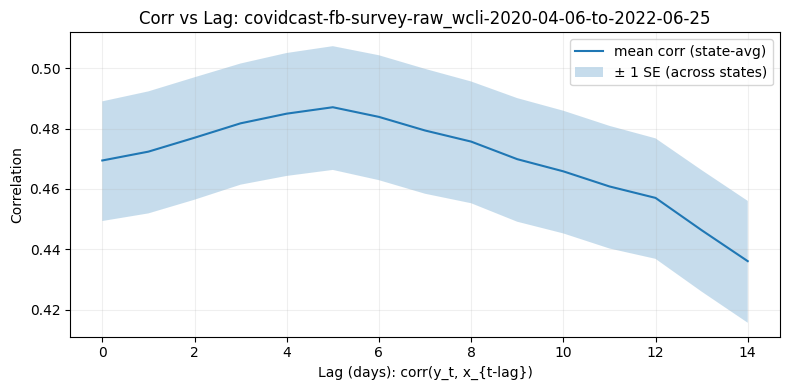

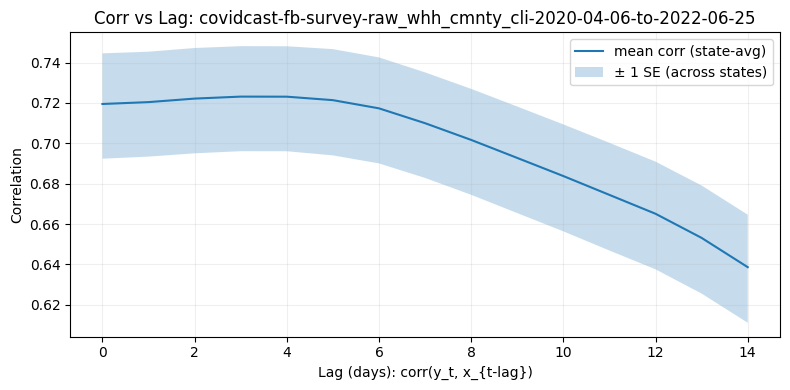

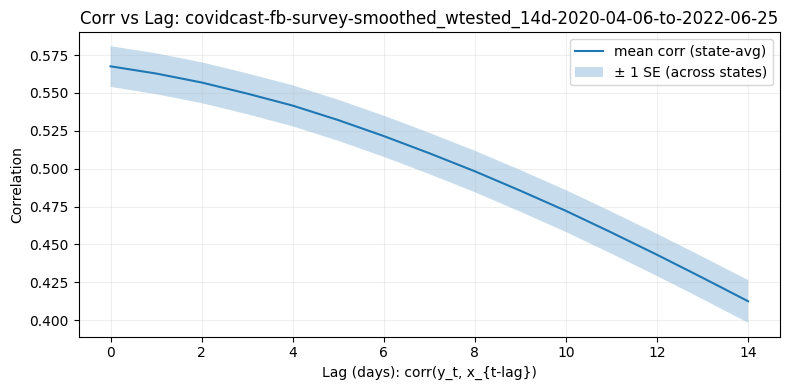

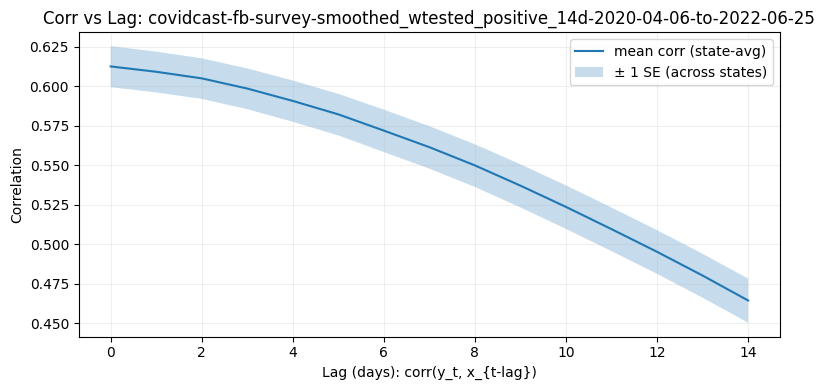

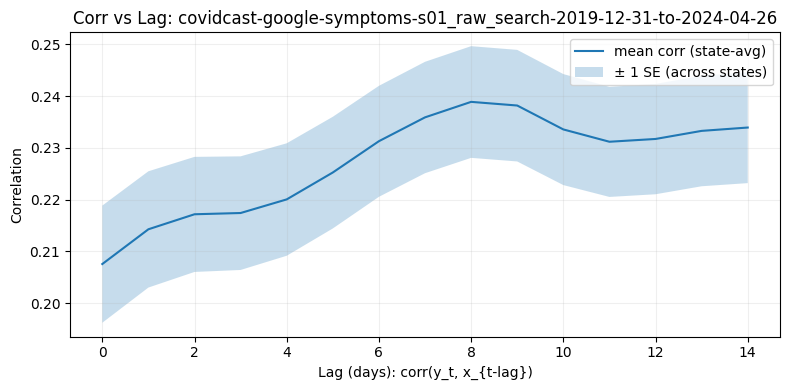

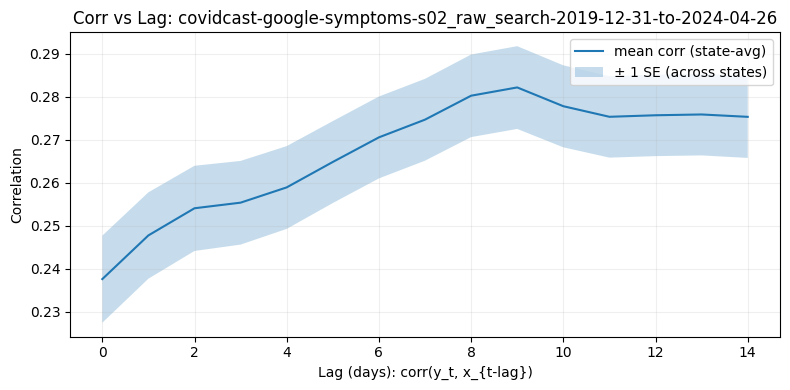

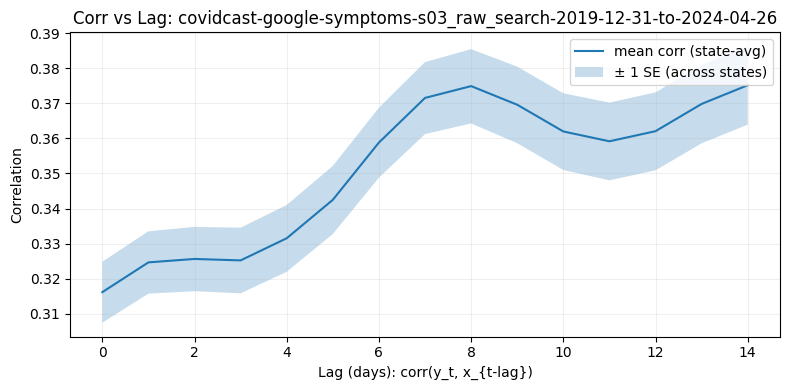

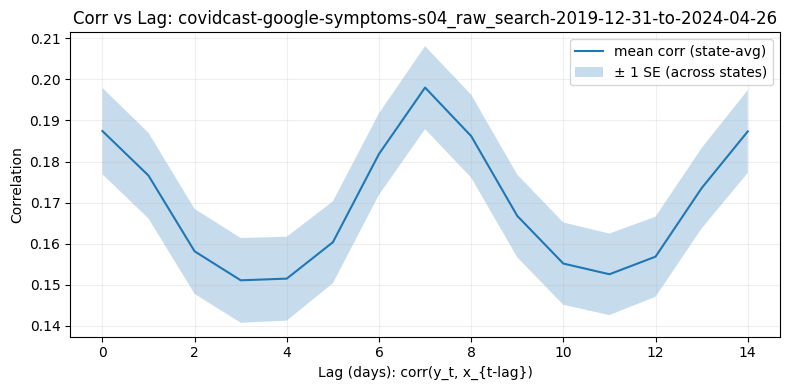

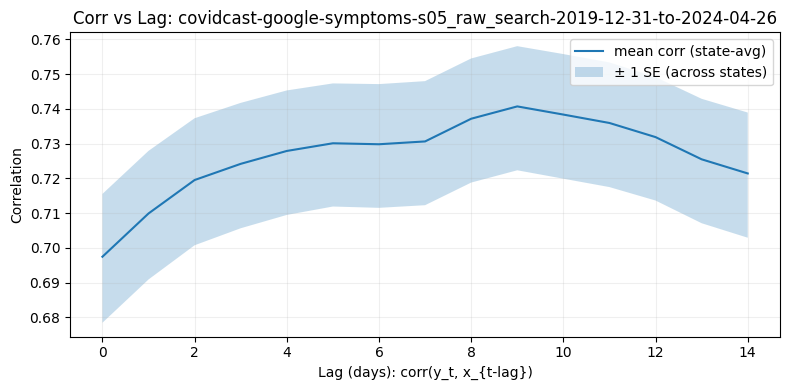

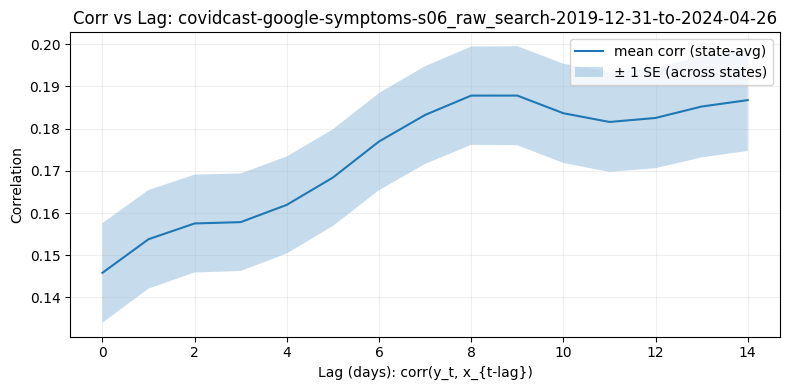

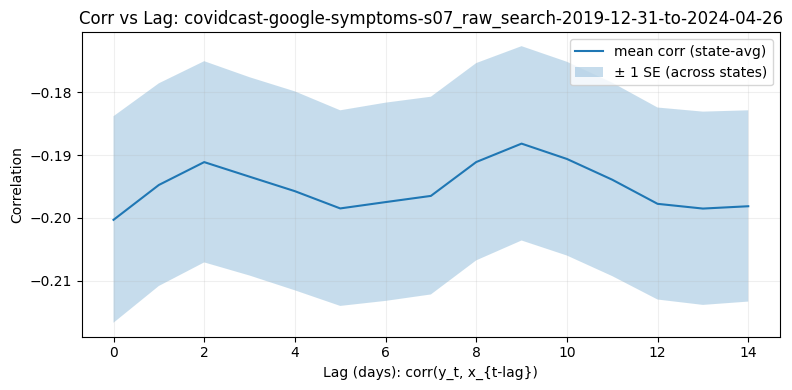

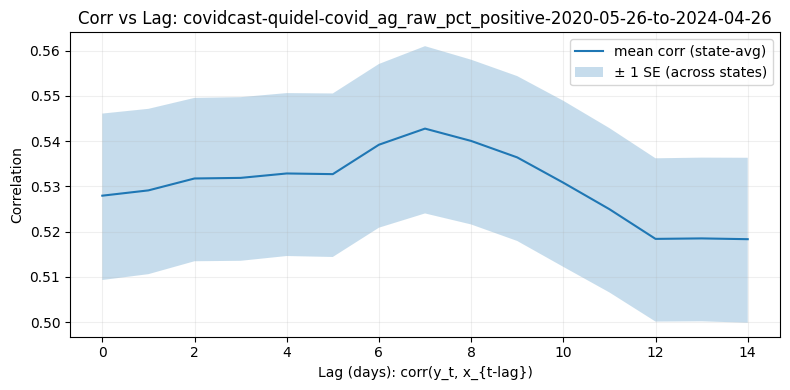

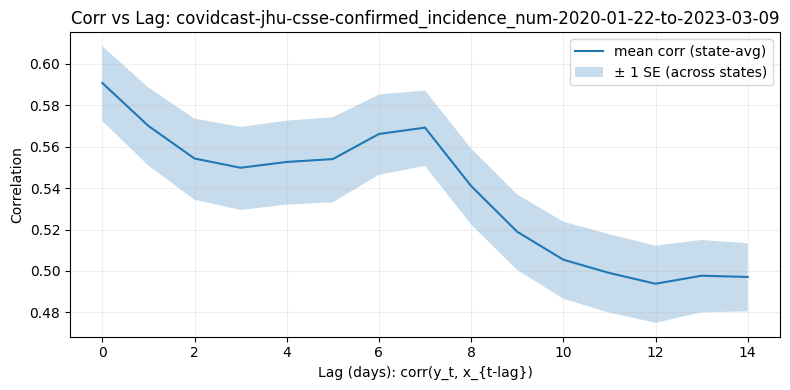

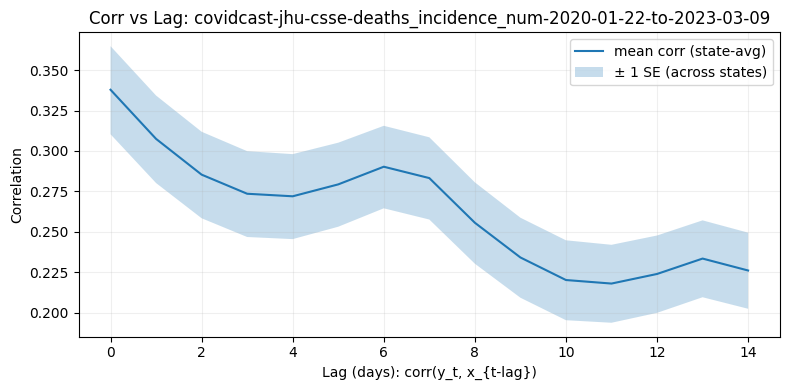

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def fisher_mean_se(rs):
    """
    rs: array-like of correlations (each from a state) for a fixed lag
    Returns: mean_r, se_r_band_low, se_r_band_high, n
    Uses Fisher z to average correlations, then back-transform.
    """
    rs = np.asarray(rs, dtype=float)
    rs = rs[np.isfinite(rs)]
    n = rs.size
    if n == 0:
        return np.nan, np.nan, np.nan, 0

    # clip to avoid inf arctanh when |r|=1
    rs = np.clip(rs, -0.999999, 0.999999)
    z = np.arctanh(rs)
    z_mean = z.mean()
    z_se = z.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0

    mean_r = np.tanh(z_mean)
    low_r  = np.tanh(z_mean - z_se)
    high_r = np.tanh(z_mean + z_se)
    return mean_r, low_r, high_r, n


def corr_by_lag_state_avg(
    target_wide: pd.DataFrame,
    aux_wide: pd.DataFrame,
    lags,
    states=None,
    min_pairs=30,
):
    """
    target_wide: (time x geo) target values
    aux_wide:    (time x geo) aux values
    lags: iterable of nonnegative integer lags (days)
    states: optional list of state codes to restrict
    min_pairs: minimum paired observations per state per lag to compute corr

    Returns DataFrame with columns:
      lag, mean_corr, lo_1se, hi_1se, n_states_used
    """
    # align time index (intersection) and keep as datetime
    y = target_wide.copy()
    x = aux_wide.copy()
    y.index = pd.to_datetime(y.index)
    x.index = pd.to_datetime(x.index)

    common_idx = y.index.intersection(x.index)
    y = y.loc[common_idx]
    x = x.loc[common_idx]

    # align states (columns)
    common_states = y.columns.intersection(x.columns)
    if states is not None:
        common_states = common_states.intersection(pd.Index(states))

    if len(common_states) == 0:
        return pd.DataFrame({"lag": list(lags), "mean_corr": np.nan, "lo_1se": np.nan, "hi_1se": np.nan, "n_states_used": 0})

    y = y[common_states]
    x = x[common_states]

    out = []
    for L in lags:
        rs = []
        # compute per-state corr between y_t and x_{t-L}
        xL = x.shift(L)  # x_{t-L}
        for st in common_states:
            yy = y[st]
            xx = xL[st]
            mask = yy.notna() & xx.notna()
            if mask.sum() < min_pairs:
                continue
            r = np.corrcoef(yy[mask].values, xx[mask].values)[0, 1]
            if np.isfinite(r):
                rs.append(r)

        mean_r, low_r, high_r, n = fisher_mean_se(rs)
        out.append({"lag": int(L), "mean_corr": mean_r, "lo_1se": low_r, "hi_1se": high_r, "n_states_used": n})

    return pd.DataFrame(out)

def plot_corr_lag_for_aux_signals(
    target_wide,
    feature_wides: dict,
    lags=range(0, 29),          # e.g., 0..28 days
    states=None,                # optionally restrict to 50 states + DC
    min_pairs=30,
    title_prefix="Corr vs Lag",
    save_dir=None               # e.g. "./corr_plots" or None
):
    if save_dir is not None:
        import os
        os.makedirs(save_dir, exist_ok=True)

    for aux_name, aux_wide in feature_wides.items():
        df = corr_by_lag_state_avg(
            target_wide=target_wide,
            aux_wide=aux_wide,
            lags=lags,
            states=states,
            min_pairs=min_pairs
        )

        # drop all-NaN results
        if df["mean_corr"].isna().all():
            print(f"[skip] {aux_name}: no usable correlations (check overlap / min_pairs).")
            continue

        fig, ax = plt.subplots(figsize=(8, 4))

        ax.plot(df["lag"], df["mean_corr"], label="mean corr (state-avg)")
        ax.fill_between(df["lag"], df["lo_1se"], df["hi_1se"], alpha=0.25, label="± 1 SE (across states)")

        # ax.axhline(0.0, linewidth=1)
        ax.set_xlabel("Lag (days): corr(y_t, x_{t-lag})")
        ax.set_ylabel("Correlation")
        ax.set_title(f"{title_prefix}: {aux_name}")
        ax.legend(loc="best")
        ax.grid(True, alpha=0.2)

        # # Optionally show how many states contributed (as a light secondary annotation)
        # # (comment out if you don't want it)
        # ax2 = ax.twinx()
        # ax2.plot(df["lag"], df["n_states_used"], linestyle="--", linewidth=1, label="# states used")
        # ax2.set_ylabel("# states used")
        # ax2.grid(False)

        # combine legends
        h1, l1 = ax.get_legend_handles_labels()
        # h2, l2 = ax2.get_legend_handles_labels()
        # ax.legend(h1 + h2, l1 + l2, loc="upper right")
        ax.legend(h1, l1, loc="upper right")

        plt.tight_layout()

        if save_dir is not None:
            outpath = os.path.join(save_dir, f"corr_lag_{aux_name}.png")
            plt.savefig(outpath, dpi=200)
            plt.close(fig)
        else:
            plt.show()


# Optional: restrict to 50 states + DC (avoids AS/VI/PR artifacts)
VALID_STATES = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","DC","FL","GA","HI","ID","IL","IN","IA","KS","KY",
    "LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH",
    "OK","OR","PA","RI","SC","SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
]

plot_corr_lag_for_aux_signals(
    target_wide=target_wide,
    feature_wides=all_signal_wides,
    lags=range(0, 15),
    states=VALID_STATES,
    min_pairs=60,
    save_dir=None            # or "./corr_plots"
)


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _restrict_rows_with_any_data(wide: pd.DataFrame, states=None):
    """Keep only rows where there is at least one non-NA across selected states."""
    df = wide.copy()
    if states is not None:
        cols = df.columns.intersection(pd.Index(states))
        df = df[cols]
    keep = df.notna().any(axis=1)
    return wide.loc[keep]

def _overlap_first_last_windows(target_wide, aux_wide, states=None, year_days=365):
    """
    Returns (target_first, aux_first, target_last, aux_last) sliced to overlap-based first/last year.
    If overlap shorter than year_days, returns as much as possible (or empty).
    """
    y = target_wide.copy()
    x = aux_wide.copy()
    y.index = pd.to_datetime(y.index)
    x.index = pd.to_datetime(x.index)

    # overlap time
    common_idx = y.index.intersection(x.index).sort_values()
    if len(common_idx) == 0:
        return None

    y = y.loc[common_idx]
    x = x.loc[common_idx]

    # further require "some data exists" on both sides (across states)
    y2 = _restrict_rows_with_any_data(y, states=states)
    x2 = _restrict_rows_with_any_data(x, states=states)

    common_idx2 = y2.index.intersection(x2.index).sort_values()
    if len(common_idx2) == 0:
        return None

    y = y.loc[common_idx2]
    x = x.loc[common_idx2]

    # choose first/last windows on the overlap index
    if len(common_idx2) <= year_days:
        # not enough for a full year; just use all overlap for both "first" and "last"
        return y, x, y, x

    first_idx = common_idx2[:year_days]
    last_idx  = common_idx2[-year_days:]

    return y.loc[first_idx], x.loc[first_idx], y.loc[last_idx], x.loc[last_idx]


def plot_corr_lag_first_vs_last_year_overlap(
    target_wide,
    feature_wides: dict,
    lags=range(0, 15),
    states=None,
    min_pairs=60,
    year_days=365,
    title_prefix="Corr vs Lag (Overlap First vs Last window)",
    save_dir=None
):
    if save_dir is not None:
        import os
        os.makedirs(save_dir, exist_ok=True)

    for aux_name, aux_wide in feature_wides.items():
        sliced = _overlap_first_last_windows(
            target_wide=target_wide,
            aux_wide=aux_wide,
            states=states,
            year_days=year_days
        )
        if sliced is None:
            print(f"[skip] {aux_name}: no overlap with target.")
            continue

        target_first, aux_first, target_last, aux_last = sliced

        # window spans (same for target/aux because we sliced on overlap index)
        first_start, first_end = target_first.index.min().date(), target_first.index.max().date()
        last_start, last_end   = target_last.index.min().date(),  target_last.index.max().date()

        label_first = f"First: {first_start} to {first_end}"
        label_last  = f"Last:  {last_start} to {last_end}"

        df_first = corr_by_lag_state_avg(
            target_wide=target_first,
            aux_wide=aux_first,
            lags=lags,
            states=states,
            min_pairs=min_pairs
        )
        df_last = corr_by_lag_state_avg(
            target_wide=target_last,
            aux_wide=aux_last,
            lags=lags,
            states=states,
            min_pairs=min_pairs
        )

        if df_first["mean_corr"].isna().all() and df_last["mean_corr"].isna().all():
            print(f"[skip] {aux_name}: no usable correlations in overlap windows.")
            continue

        fig, ax = plt.subplots(figsize=(8, 4))

        # First overlap window
        ax.plot(df_first["lag"], df_first["mean_corr"], label=label_first)
        ax.fill_between(df_first["lag"], df_first["lo_1se"], df_first["hi_1se"], alpha=0.20)

        # Last overlap window
        ax.plot(df_last["lag"], df_last["mean_corr"], label=label_last, linestyle="--")
        ax.fill_between(df_last["lag"], df_last["lo_1se"], df_last["hi_1se"], alpha=0.20)

        ax.set_xlabel("Lag (days): corr(y_t, x_{t-lag})")
        ax.set_ylabel("Correlation")
        ax.set_title(f"{title_prefix}: {aux_name}")
        ax.grid(True, alpha=0.2)
        ax.legend(loc="best")
        plt.tight_layout()

        if save_dir is not None:
            import os
            outpath = os.path.join(save_dir, f"corr_lag_overlap_first_last_{aux_name}.png")
            plt.savefig(outpath, dpi=200)
            plt.close(fig)
        else:
            plt.show()



/net/dali/home/mscbio/rul98/miniconda3/envs/struct/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/net/dali/home/mscbio/rul98/miniconda3/envs/struct/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


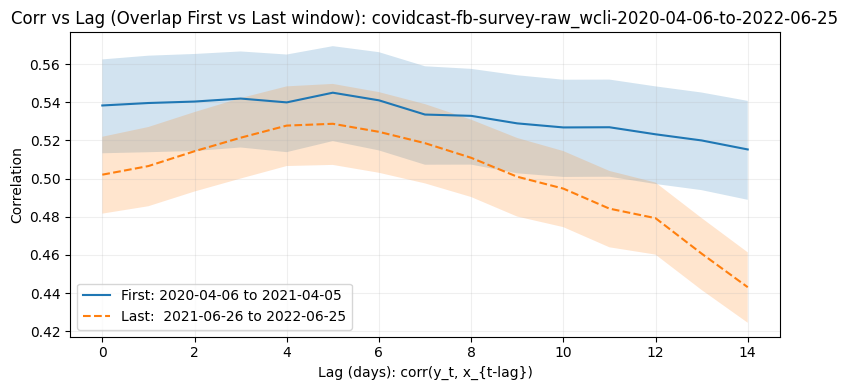

/net/dali/home/mscbio/rul98/miniconda3/envs/struct/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/net/dali/home/mscbio/rul98/miniconda3/envs/struct/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


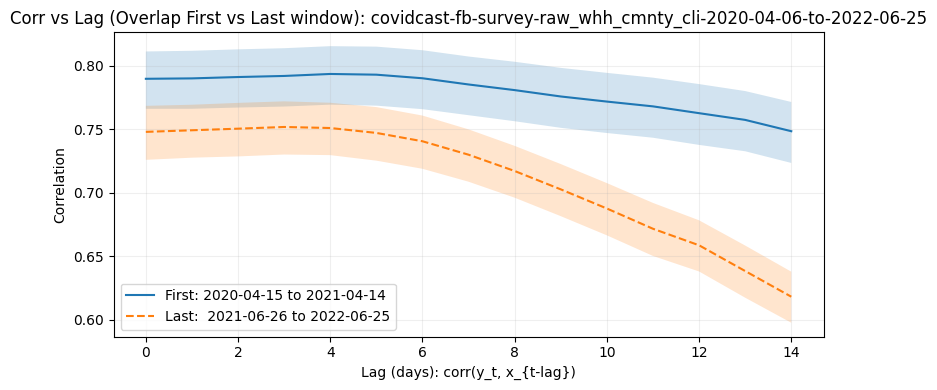

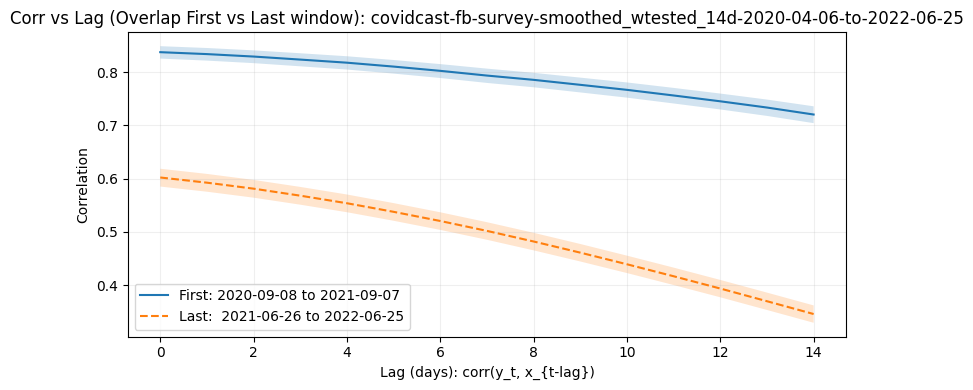

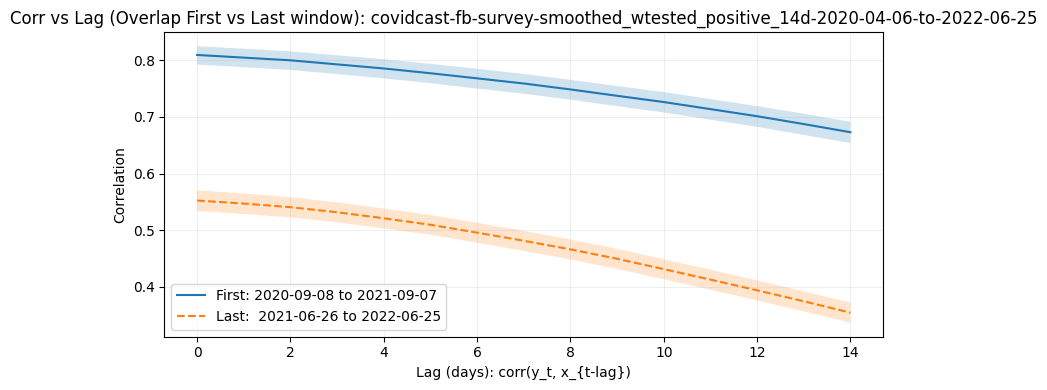

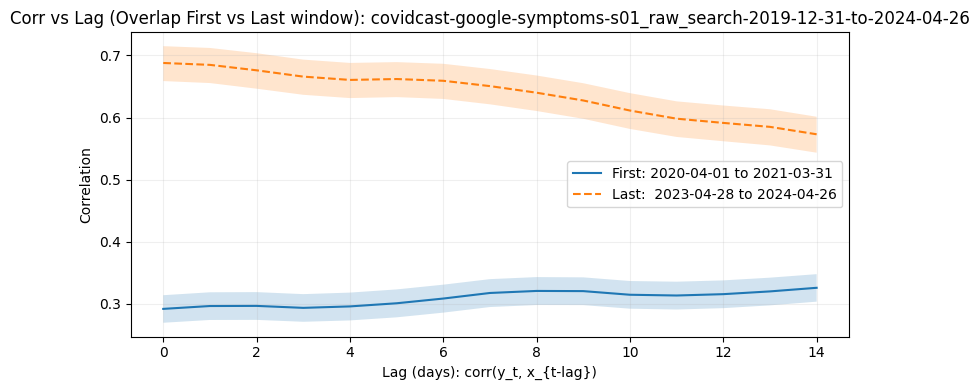

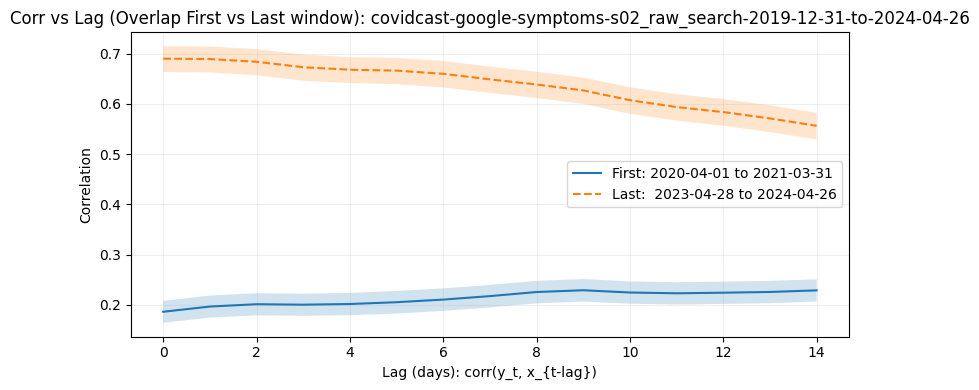

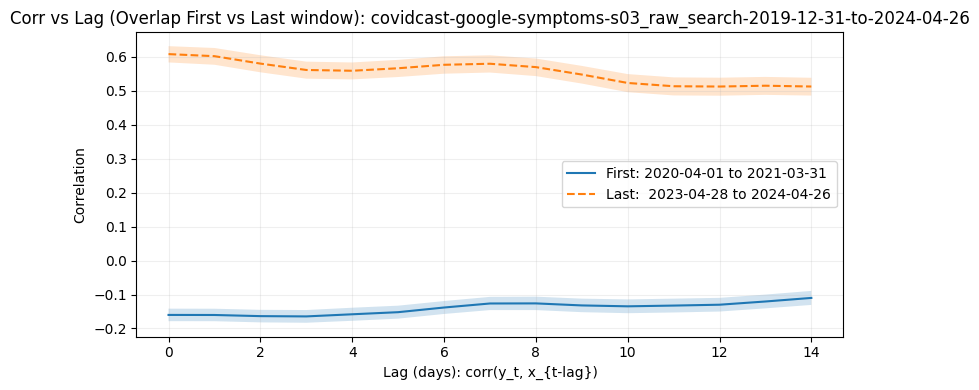

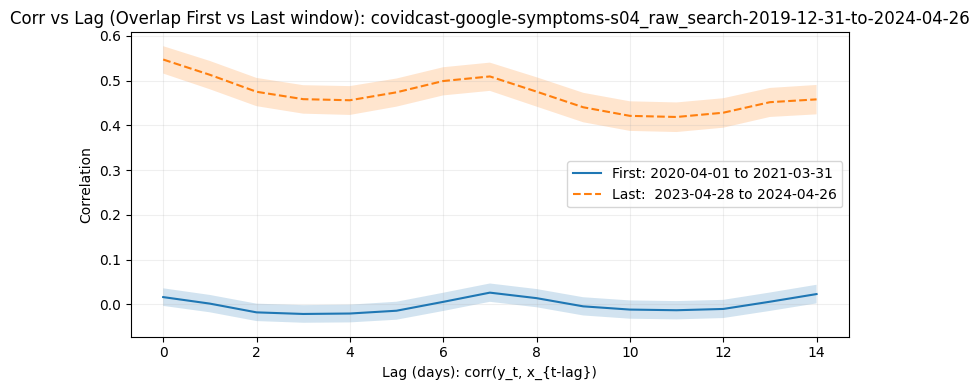

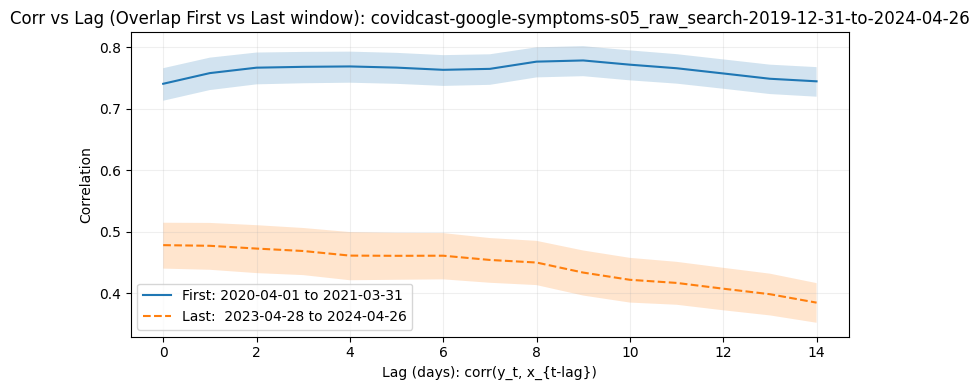

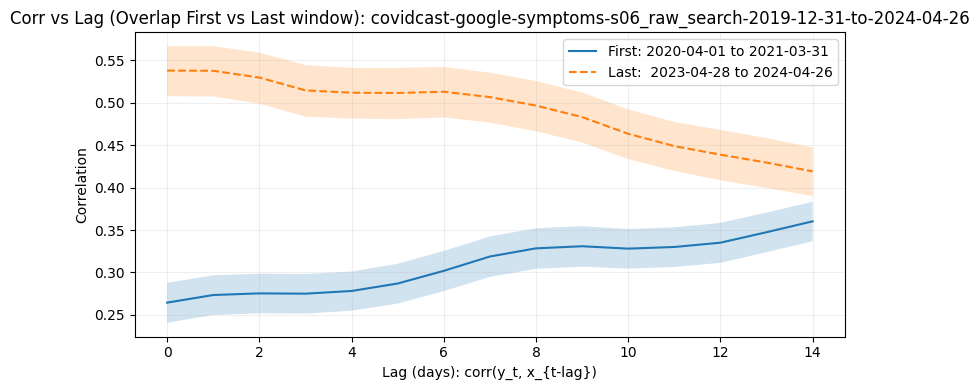

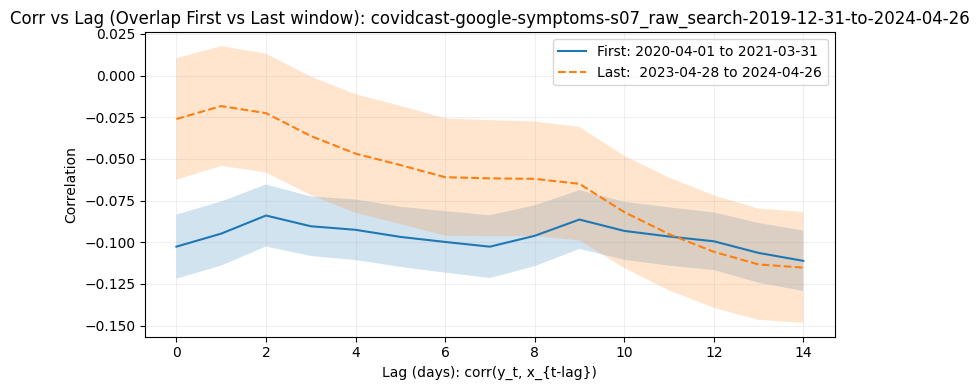

/net/dali/home/mscbio/rul98/miniconda3/envs/struct/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/net/dali/home/mscbio/rul98/miniconda3/envs/struct/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/net/dali/home/mscbio/rul98/miniconda3/envs/struct/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/net/dali/home/mscbio/rul98/miniconda3/envs/struct/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


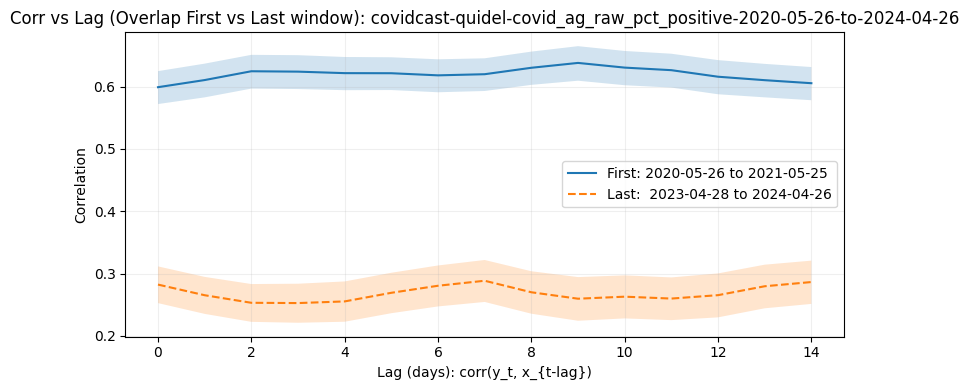

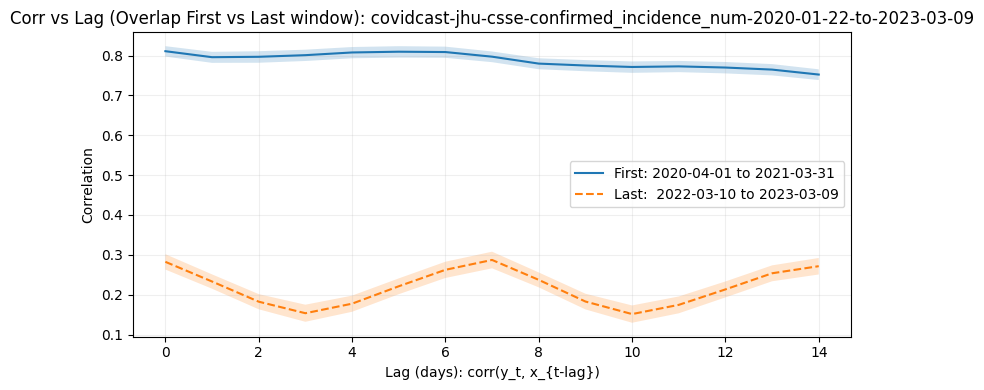

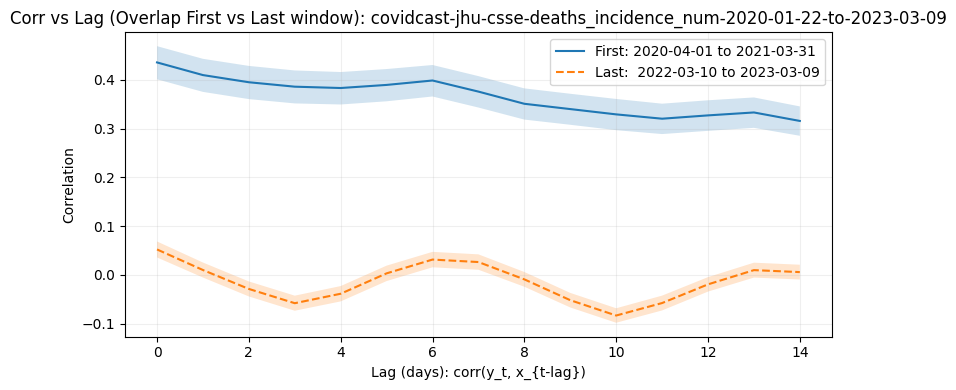

In [13]:
plot_corr_lag_first_vs_last_year_overlap(
    target_wide=target_wide,
    feature_wides=all_signal_wides,   # or feature_wides if you only want auxiliary
    lags=range(0, 15),
    states=VALID_STATES,
    min_pairs=60,
    year_days=365,
    save_dir=None
)


In [14]:
def predict_named(X, feat_names_ref, coef_series, intercept):
    w = coef_series.reindex(feat_names_ref).fillna(0.0).to_numpy()
    return X @ w + intercept

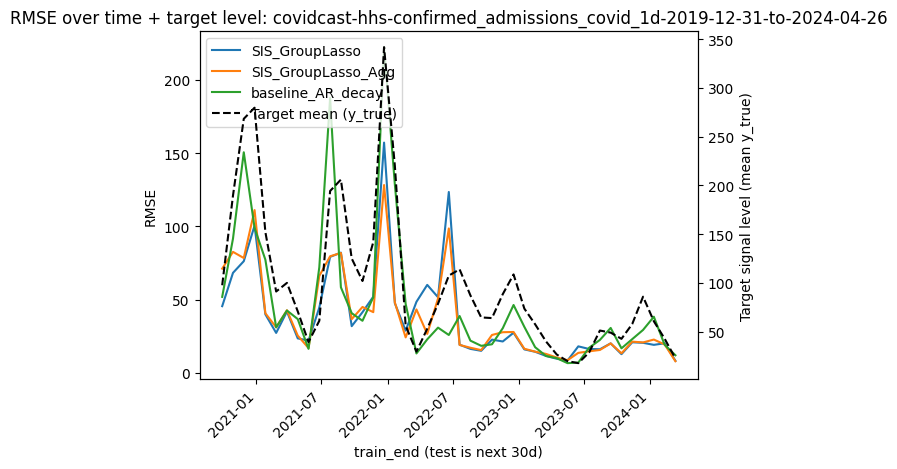

0.05
                                       target_signal               model  \
0  covidcast-hhs-confirmed_admissions_covid_1d-20...      SIS_GroupLasso   
1  covidcast-hhs-confirmed_admissions_covid_1d-20...  SIS_GroupLasso_Agg   
2  covidcast-hhs-confirmed_admissions_covid_1d-20...   baseline_AR_decay   

        RMSE        MAE        N  
0  49.701729  20.180633  69660.0  
1  48.072534  20.204051  69660.0  
2  65.844132  23.895727  69660.0  


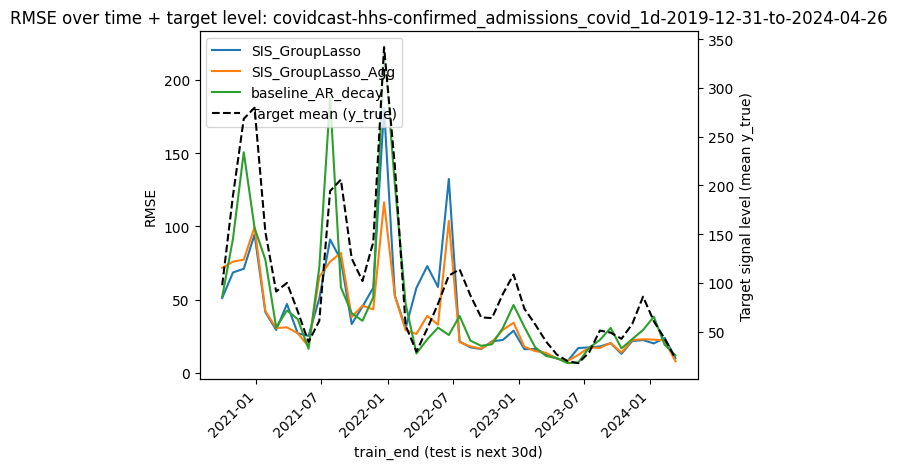

0.1
                                       target_signal               model  \
0  covidcast-hhs-confirmed_admissions_covid_1d-20...      SIS_GroupLasso   
1  covidcast-hhs-confirmed_admissions_covid_1d-20...  SIS_GroupLasso_Agg   
2  covidcast-hhs-confirmed_admissions_covid_1d-20...   baseline_AR_decay   

        RMSE        MAE        N  
0  53.676431  21.524579  69660.0  
1  46.418468  20.279024  69660.0  
2  65.844132  23.895727  69660.0  


In [ ]:
# =========================
# Config
# =========================
RETRAIN_EVERY_DAYS = 30
TEST_DAYS = 30
VAL_DAYS = 30
TRAIN_WINDOW_DAYS = 180  # rolling training window to handle non-stationarity

# feature lags (exogenous) and AR lags must have SAME LENGTH for equal-size groups
FEATURE_LAGS = (0, 3, 6, 13)    # use contemporaneous + weekly + biweekly lags
AR_LAGS      = (7, 10, 14, 20)   # different delay set, same length


# Aggregation parameters
K_CANDIDATES = 5
S_SCREEN = 100    # top-s entries in sparsity-index screening
Q_TAU = 1.0       # temperature for Q-aggregation

# Baseline (AR-only) gamma grid for exp decay weights
BASELINE_GAMMAS = [0.0, 0.01, 0.05, 0.1]

# Missing handling
FILL_MISSING_WITH_ZERO = True   # if False, drop rows with NA more aggressively
# LIMIT_INTERP_DAYS = 3           # small gap interpolation (optional)

# GroupLasso strength (you can tune this too; keeping simple)
for GL_ALPHA in [0.05, 0.1, 0.15]:
    target_wide = target_wide.sort_index()
    target_idx = pd.to_datetime(target_wide.index)
    feature_wides_raw = {k: v for k, v in all_signal_wides.items() if k != target_name}
    feature_wides = {}
    for sig_name, wide in feature_wides_raw.items():
        if wide is None or len(wide) == 0:
            continue
        wide = wide.sort_index().copy()
        wide.index = pd.to_datetime(wide.index)
        wide_aligned = wide.reindex(target_idx)
        wide_aligned = wide_aligned.mask(wide_aligned < 0, 0.0)
        # wide_aligned = wide_aligned.interpolate(method="time", limit=LIMIT_INTERP_DAYS, limit_area="inside")
        # wide_aligned = wide_aligned.ffill(limit=LIMIT_INTERP_DAYS).bfill(limit=LIMIT_INTERP_DAYS)
        wide_aligned = wide_aligned.fillna(0.0)
        nonconstant_cols = (wide_aligned.abs().sum(axis=0) > 0)
        wide_aligned = wide_aligned.loc[:, nonconstant_cols]
        if wide_aligned.shape[1] == 0:
            continue
        feature_wides[sig_name] = wide_aligned

    # Determine states common across target + (at least some) features
    states = [c for c in target_wide.columns if c.isalpha() and len(c) == 2]  # typical state abbrev
    states = [st for st in states if st in target_wide.columns]
    if len(states) == 0:
        states = list(target_wide.columns)

    train_ends = compute_walkforward_schedule(target_wide.index)

    group_size = len(FEATURE_LAGS)
    assert len(AR_LAGS) == group_size, "AR_LAGS must have same length as FEATURE_LAGS for equal-size groups."

    pred_rows = []

    for train_end in train_ends:
        train_end = pd.to_datetime(train_end)
        train_start = train_end - pd.Timedelta(days=TRAIN_WINDOW_DAYS - 1)
        val_start = train_end - pd.Timedelta(days=VAL_DAYS - 1)
        test_start = train_end + pd.Timedelta(days=1)
        test_end = train_end + pd.Timedelta(days=TEST_DAYS)

        # Fit GroupLasso for ALL states in this window (target-only training per state)
        # Store coefs/intercepts and d = X^T y / T for candidate selection
        fit_by_state = {}
        d_by_state = {}

        # also store AR-only baseline (gamma chosen per state)
        baseline_by_state = {}

        # Pre-build datasets per state (train/val/test)
        data_cache = {}

        for st in states:
            # build full window design up to test_end so we can slice train/val/test cleanly
            built = build_design_for_state(
                target_wide, feature_wides, st,
                start_date=train_start, end_date=test_end,
                feature_lags=FEATURE_LAGS, ar_lags=AR_LAGS
            )
            if built is None:
                continue
            X_all, y_all, dates_all, feat_names, group_names = built
            data_cache[st] = (X_all, y_all, dates_all, feat_names, group_names)

            # indices for train/val/test within aligned dates_all
            dates_all = pd.to_datetime(dates_all)
            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)

            if idx_train.sum() < 50 or idx_val.sum() < 10 or idx_test.sum() < 5:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ---------- Baseline: AR-only with decay gamma tuned on val ----------
            # AR columns are last len(AR_LAGS) columns by construction
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]
            best_gamma = fit_ar_baseline_decay(
                Xtr_ar, y_tr, Xva_ar, y_va, train_dates=d_tr, train_end=train_end, gammas=BASELINE_GAMMAS
            )
            baseline_by_state[st] = {"gamma": best_gamma}

            # ---------- SIS-GroupLasso fit ----------
            active_g, coef, intercept = SIS_grpLasso_KKT(
                X_expanded=X_tr, y=y_tr,
                group_size=group_size, alpha=GL_ALPHA, weights=None
            )
            fit_by_state[st] = {
                "coef": pd.Series(coef, index=feat_names),
                "intercept": intercept,
                "active_g": active_g
            }

            # d statistic for candidate selection (use training)
            d_by_state[st] = (X_tr.T @ y_tr) / max(len(y_tr), 1)

        if len(fit_by_state) < 2:
            continue

        # Now evaluate per state
        for st in list(fit_by_state.keys()):
            X_all, y_all, dates_all, feat_names, group_names = data_cache[st]
            dates_all = pd.to_datetime(dates_all)

            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)
            if idx_train.sum() < 50 or idx_val.sum() < 10 or idx_test.sum() < 5:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ----- Baseline predictions -----
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]

            g = baseline_by_state[st]["gamma"]
            backcast_lag = (train_end - d_tr).days.astype(float).values
            w = np.exp(-g * backcast_lag)
            w = w / (w.max() if w.max() > 0 else 1.0)
            yhat_base = weighted_ols_fit_predict(Xtr_ar, y_tr, w, Xte_ar)

            # ----- SIS-GroupLasso target-only predictions -----
            target_feat_names = feat_names
            fit0 = fit_by_state[st]
            yhat_gl = predict_named(X_te, target_feat_names, fit0["coef"], fit0["intercept"])

            # ----- Aggregation -----
            # candidate states via sparsity index
            # all_states_here = [s for s in fit_by_state.keys() if s in d_by_state]
            all_states_here = [s for s in fit_by_state.keys() if s in d_by_state and s in VALID_STATES]
            cand_states = select_candidate_states(d_by_state, st, all_states_here, s=S_SCREEN, K=K_CANDIDATES)
            cand_all = [st] + cand_states

            # build Yhat on validation (on target state's X_va) and test (on target state's X_te)
            Yhat_val = []
            Yhat_test = []
            for s2 in cand_all:
                fit2 = fit_by_state[s2]
                Yhat_val.append(predict_named(X_va, target_feat_names, fit2["coef"], fit2["intercept"]))
                Yhat_test.append(predict_named(X_te, target_feat_names, fit2["coef"], fit2["intercept"]))
            Yhat_val = np.column_stack(Yhat_val)
            Yhat_test = np.column_stack(Yhat_test)

            w_agg = q_aggregate_weights(y_va, Yhat_val, tau=Q_TAU)
            yhat_agg = Yhat_test @ w_agg

            # store row-level predictions
            for i, dt in enumerate(d_te):
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "baseline_AR_decay",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_base[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_gl[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso_Agg",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_agg[i]),
                })

    pred_df = pd.DataFrame(pred_rows)

    # summary metrics
    summary = (
        pred_df.groupby(["target_signal", "model", "geo_value"])
        .apply(lambda g: pd.Series({
            "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
            "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
            "N": len(g)
        }))
        .reset_index()
    )

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    pred_df["train_end"] = pd.to_datetime(pred_df["train_end"])
    pred_df["time_value"] = pd.to_datetime(pred_df["time_value"])

    def rmse(x):
        return np.sqrt(np.mean((x["y_true"].values - x["y_pred"].values) ** 2))

    # A) RMSE per retrain step (each step = next 30-day test period)
    rmse_by_step = (
        pred_df
        .groupby(["target_signal", "model", "train_end"])
        .apply(rmse)
        .rename("RMSE")
        .reset_index()
        .sort_values(["target_signal", "model", "train_end"])
    )

    sig = pred_df["target_signal"].iloc[0]
    tmp = rmse_by_step[rmse_by_step["target_signal"] == sig].copy()

    # Build a "target level" series aligned to train_end:
    # use mean(y_true) over the corresponding test block (all states pooled)
    target_level = (
        pred_df[pred_df["target_signal"] == sig]
        .groupby("train_end")["y_true"]
        .mean()
        .rename("target_mean")
        .reset_index()
    )

    # Merge so x-axis aligns
    tmp2 = tmp.merge(target_level, on="train_end", how="left")

    fig, ax = plt.subplots()

    # left axis: RMSE by model
    for m, g in tmp2.groupby("model"):
        ax.plot(g["train_end"], g["RMSE"], label=m)
    ax.set_xlabel("train_end (test is next 30d)")
    ax.set_ylabel("RMSE")

    # right axis: target signal level
    ax2 = ax.twinx()
    ax2.plot(target_level["train_end"], target_level["target_mean"], color = 'k', linestyle="--", label="Target mean (y_true)")
    ax2.set_ylabel("Target signal level (mean y_true)")

    # combined legend (both axes)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    ax.set_title(f"RMSE over time + target level: {sig}")
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()

    print(GL_ALPHA)
    print(pred_df.groupby(["target_signal", "model"]).apply(lambda g: pd.Series({
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
        "N": len(g)
    })).reset_index())